In [3]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import numpy as np
import matplotlib.pyplot as plt

In [21]:
# Get cpu or gpu device for training.
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device}")
device

Using mps


'mps'

# Exercise 1: Convolutional Neural Networks


In this exercise, you will train a simple CNN to classify images from the CIFAR10 dataset.


1. Download the CIFAR10 dataset using `torchvision.datasets.CIFAR10`, and build the train and test dataloaders, setting the batch size to 32 and activating reshuffling at each epoch for the train data by setting `shuffle=True`. Visualize some images and their different color channels.

In [22]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

training_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_dataloader = DataLoader(
    training_data,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=None,
    pin_memory=False,
 )
test_dataloader = train_dataloader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=None,
    pin_memory=False,
 )

batch_size=32

Files already downloaded and verified
Files already downloaded and verified


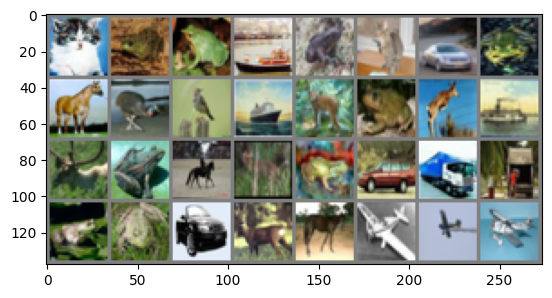

['cat', 'frog', 'cat', 'ship', 'frog', 'cat', 'car', 'frog', 'horse', 'bird', 'bird', 'ship', 'deer', 'frog', 'deer', 'ship', 'deer', 'frog', 'horse', 'deer', 'frog', 'car', 'truck', 'truck', 'frog', 'frog', 'car', 'deer', 'horse', 'plane', 'plane', 'plane']


In [23]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5 # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_dataloader)

images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print([classes[labels[j]] for j in range(batch_size)])

In [24]:
images.shape

torch.Size([32, 3, 32, 32])

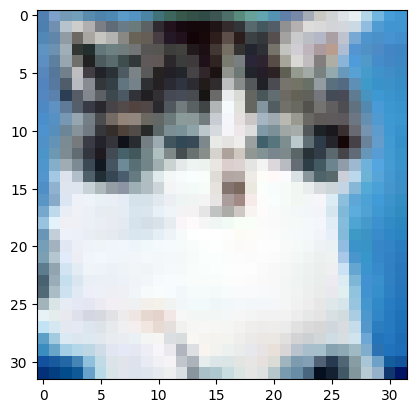

In [25]:
imshow(images[0])

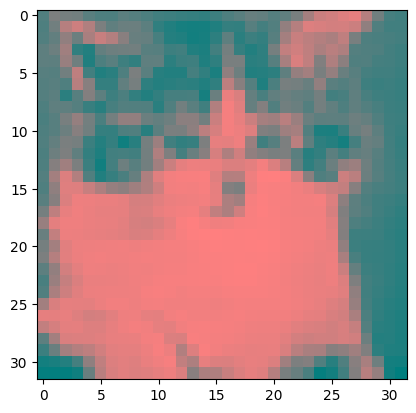

In [26]:
im_red = images[0].clone()
im_red[1:3,:,:] = 0.
imshow(im_red) # Red channel of the image

2. Define a function returning a convolutional neural network built with `nn.Sequential`. Use a first layer of 6 convolutional channels with filter size 5, a max-pooling layer over a $2 \times 2$ window, a second convolutional layer made of 16 channels with filter size 5, another $2 \times 2$ max-pooling layer, two dense layers with 120 and 84 neurons respectively, and a final linear layer with 10 outputs.

In [27]:
def initialize_cnn():

    model = nn.Sequential(
          nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
          nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
          nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Flatten(),
          nn.Linear(400, 120),
          nn.ReLU(),
          nn.Linear(120, 84),
          nn.ReLU(),
          nn.Linear(84, 10)
        )
    return model

3. Using the cross-entropy loss and SGD with learning rate 0.01, train the model for 5 epochs. After training, compute the accuracy on the test set.

In [28]:
from torch.optim import SGD

In [29]:
model = initialize_cnn()
print(model)
loss_fun = torch.nn.CrossEntropyLoss()
optm = SGD(model.parameters(), lr=0.01)

Sequential(
  (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=120, bias=True)
  (8): ReLU()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=10, bias=True)
)


In [30]:
def train(dataloader, model, loss_fn, optimizer):
    '''
    This function implements the train loop. It iterates over the training dataset
    and try to converge to optimal parameters.
    '''
    size = len(dataloader.dataset)
    model.train() # Set the model to training mode
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction and loss
        pred = model(X) # Pass the data to the model to execute the model forward
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward() # Compute gradients of the loss w.r.t parameters (backward pass)
        optimizer.step() # Do a gradient descent step and adjust parameters
        optimizer.zero_grad() # Reset the gradients of model parameters to zero (gradients by default add up)

        if batch % size//3 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [31]:
def test(dataloader, model, loss_fn):
    '''
    This function implements the validation/test loop. It iterates over the test
    dataset to check if the model performance is improving.
    '''
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() # Set the model to evaluation mode
    test_loss, correct = 0, 0
    with torch.no_grad(): # Do not track gradients while evaluating (faster)
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item() # Compute CE loss on the batch
            correct += (pred.argmax(1) == y).type(torch.float).sum().item() # Compute classification error
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [32]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n")
    train(train_dataloader, model, loss_fun, optm)
    test(test_dataloader, model, loss_fun)

print("Done!")

Epoch 1



RuntimeError: Input type (MPSFloatType) and weight type (torch.FloatTensor) should be the same

# Exercise 2: Momentum

1. Making an analogy with a physical system, we can think of the negative gradient as a force moving a particle through parameter space, following Newton’s laws. Adding a momentum or inertia term, the optimization algorithm remembers the directions of the past gradients and continues to move in their direction. Mathematically,
\begin{equation}
    v_t = \gamma v_{t-1} + \eta \nabla_\theta L(\theta_t)
\end{equation}
\begin{equation}
    \theta_{t+1} = \theta_t - v_t,
\end{equation}
where $\gamma \in [0,1]$ is the momentum parameter, $\eta$ the learning rate, and $\theta$ the parameters of the model. Momentum helps the optimization dynamics gain speed in directions with persistent small gradients and suppresses oscillations. Repeat training, adding `momentum=0.9` to the SGD dynamics.

In [ ]:
model = initialize_cnn()

optm_momentum = SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n")
    train(train_dataloader, model, loss_fun, optm_momentum)
    test(test_dataloader, model, loss_fun)

print("Done!")

# Exercise 3: Feature Maps

1. Using t`orch.fx`, we can visualize the transformations of an input inside our neural network. For different input images, check the outputs of the first convolutional layer, of the first ReLU application, and of the first pooling layer.


In [ ]:
from torchvision.models.feature_extraction import get_graph_node_names
from torchvision.models.feature_extraction import create_feature_extractor

nodes, _ = get_graph_node_names(model)
print(nodes) # Prints the nn.Sequential layer names

feature_extractor = create_feature_extractor(
	model, return_nodes=['0', '1', '2']) # Outputs of first conv. layer, ReLU, and first pooling layer

In [ ]:
dataloader = DataLoader(training_data, batch_size=batch_size)

image = images[0].clone()

out = feature_extractor(image.unsqueeze(0)) # Return dictionary with the feature maps of 'image'

imshow(image)

print('conv1')
for i in range(6):
    plt.imshow(out['0'][0,i].detach())
    plt.show()

print('relu')
for i in range(6):
    plt.imshow(out['1'][0,i].detach())
    plt.show()

print('pool')
for i in range(6):
    plt.imshow(out['2'][0,i].detach())
    plt.show()

2. Can we look at what a particular neuron reacts to? What are the features learned by deep models? A simple idea to visualize these features, called activation maximization, consists in looking for the input with bounded norm that maximizes the activation of a given neuron ($x^* = \arg \max_{x: \; \|x\|=1} h_i^{\ell}(x,\theta^*)$, where $h_i^\ell$ is the activation of the neuron $i$ at layer $\ell$ of a trained network). Open https://distill.pub/2017/feature-visualization/appendix and check how the neurons in different layers of the GoogLeNet network are specializing to recognize features with various complexity, from simple textures to meaningful semantic concepts!